# 神經網路計算(一)

In [1]:
import numpy as np

In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [3]:
x=1

In [4]:
y=sigmoid(x)
print(y)

0.7310585786300049


In [5]:
x=np.array([-1.0, 1.0, 2.0])

In [6]:
y=sigmoid(x)
print(y)

[0.26894142 0.73105858 0.88079708]


In [7]:
import matplotlib.pylab as plt

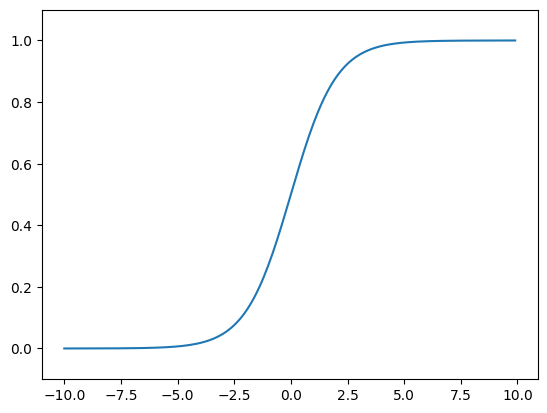

In [8]:
X = np.arange(-10.0, 10.0, 0.1)
Y = sigmoid(X)
plt.plot(X, Y)
plt.ylim(-0.1, 1.1)
plt.show()

In [11]:
def softmax(x):
    c=np.max(x)
    x = x - c
    return np.exp(x) / np.sum(np.exp(x))

In [12]:
x=np.array([1000, 1001,999,1002])

In [ ]:
np.max(x)

np.int64(1002)

In [13]:
x-np.max(x)

array([-2, -1, -3,  0])

In [14]:
x=x-np.max(x)
np.exp(x)

array([0.13533528, 0.36787944, 0.04978707, 1.        ])

In [15]:
np.sum(np.exp(x))

np.float64(1.553001792775919)

In [16]:
y=softmax(x)
print(y)

[0.08714432 0.23688282 0.0320586  0.64391426]


In [17]:
np.sum(y)

np.float64(1.0)

In [18]:
X=np.array([1, 2])
X.shape

(2,)

In [19]:
W=np.array([[1, 3, 5], [2, 4, 6]])
W.shape

(2, 3)

In [20]:
print(W)

[[1 3 5]
 [2 4 6]]


In [21]:
b=np.array([4, 8, 2])

In [22]:
z=np.dot(X, W)+b
print(z)

[ 9 19 19]


In [23]:
y=sigmoid(z)
print(y)

[0.99987661 0.99999999 0.99999999]


In [ ]:
y=relu(z)
print(y)

[ 9 19 19]


In [ ]:
y=softmax(z)
print(y)

[2.26994496e-05 4.99988650e-01 4.99988650e-01]


In [24]:
X=np.array([1.0, 2.0,3.0,4.0,5.0,6.0])

#### 第一層：三個神經元

In [26]:
W1=np.array([[0.1,0.2, 0.3,0.4, 0.5], [0.2,0.3, 0.4,0.5, 0.6],[0.3,0.4,0.5,0.6,0.7],[0.4,0.5,0.6,0.7,0.8,],[0.5,0.6,0.7,0.8,0.9],[0.6,0.7,0.8,0.9,1.0]])
b1=np.array([0.1, 0.2, 0.3,0.4,0.5])

In [27]:
print(X.shape)
print(W1.shape)
print(b1.shape)

(6,)
(6, 5)
(5,)


In [30]:
z1=np.dot(X, W1)+b1
print(z1)
print(z1.shape)

[ 9.2 11.4 13.6 15.8 18. ]
(5,)


In [31]:
h1=relu(z1)
print(h1)
print(h1.shape)

[ 9.2 11.4 13.6 15.8 18. ]
(5,)


#### 第二層：兩個神經元

In [35]:
W2=np.array([[0.1, 0.2,0.3,0.4], [0.2,0.3,0.4, 0.5], [0.3,0.4,0.5, 0.6],[0.4,0.5,0.6,0.7],[0.5,0.6,0.7,0.8]])
b2=np.array([0.1, 0.2,0.3,0.4])

In [36]:
print(h1.shape)
print(W2.shape)
print(b2.shape)

(5,)
(5, 4)
(4,)


In [37]:
z2=np.dot(h1, W2)+b2
print(z2)
print(z2.shape)

[22.7 29.6 36.5 43.4]
(4,)


In [38]:
h2=relu(z2)
print(h2)
print(h2.shape)

[22.7 29.6 36.5 43.4]
(4,)


#### 第三層(輸出層)：兩個神經元

In [39]:
W3=np.array([[0.1,0.2, 0.3,0.4], [0.2,0.3, 0.4,0.5],[0.3,0.4,0.5,0.6],[0.4,0.5,0.6,0.7]])
b3=np.array([0.1, 0.2,0.3,0.4])

In [40]:
print(h2.shape)
print(W3.shape)
print(b3.shape)

(4,)
(4, 4)
(4,)


In [41]:
z3=np.dot(h2, W3)+b3
print(z3)
print(z3.shape)

[36.6  49.92 63.24 76.56]
(4,)


In [42]:
y_hat=softmax(z3)  # y_hat是神經網路在目前的參數下所得到的計算結果
print(y_hat)

[4.42172562e-18 2.69397952e-12 1.64133333e-06 9.99998359e-01]


## Loss fnctions
* 用來衡量神經網路計算出的結果**y_hat**與真正的結果**y**之間的誤差
* **Cross entropy error (交叉熵誤差)**：常用於分類問題

In [ ]:
# cross_entropy_error用來計算神經網路計算出的結果y_hat與真正的結果y之間的誤差
def cross_entropy_error(y_hat, y):
    return -np.sum(y * np.log(y_hat + 1e-7))

In [ ]:
y=[1, 0]    # y代表是X的真正的結果，即X屬於第1種類的機率為1，屬於第2類的機率為0

In [ ]:
np.log(y_hat + 1e-7)

array([-0.94083081, -0.49479355])

In [ ]:
y*np.log(y_hat + 1e-7)

array([-0.94083081, -0.        ])

In [ ]:
-np.sum(y * np.log(y_hat + 1e-7))

np.float64(0.9408308128473432)

In [ ]:
cross_entropy_error(y_hat, y)

np.float64(0.9408308128473432)